<a href="https://colab.research.google.com/github/lakshitaison/firstproject/blob/main/Breast_Cancer_Prediction_PCA_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎗️ Breast Cancer Prediction using PCA and SVD

**Machine Learning Mini Project**

---

## Step 1 — Import Libraries

First we import all the libraries we need. We use:
- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for plots
- `sklearn` for ML models, preprocessing, and evaluation

In [1]:
# uncomment the line below if running for the first time
# !pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, ConfusionMatrixDisplay
)
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load the Dataset

Upload the CSV file and load it into a pandas DataFrame.
You can use the Google Drive mount option or the file upload option.

In [7]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# --- Option 2: Mount Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Breast_Cancer.csv')

# --- Option 3: Load directly if already in /content ---
# df = pd.read_csv('/content/breastcancer_-_Breast_Cancer.csv')

print('Dataset loaded!')
print('Shape:', df.shape)
print()
print('First 5 rows:')
df.head()

Saving breastcancer - Breast_Cancer.csv to breastcancer - Breast_Cancer (1).csv
Dataset loaded!
Shape: (4024, 16)

First 5 rows:


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,Other,Married,T2,N3,IIIC,Moderately differentiated,2,Regional,40,Positive,Positive,19,11,1,Alive
1,46,White,Divorced,T1,N1,IIA,Moderately differentiated,2,Regional,19,Positive,Positive,26,1,2,Dead
2,67,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,25,Positive,Positive,4,1,2,Dead
3,47,Other,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,45,Positive,Positive,25,9,2,Alive
4,55,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,15,Positive,Positive,9,1,3,Alive


## Step 3 — Exploratory Data Analysis (EDA)

Let's understand the dataset — check its size, types, missing values, and class balance.

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  S

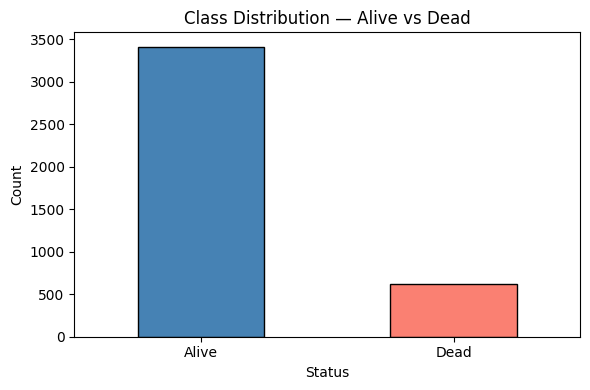

In [8]:
print('Dataset Info:')
print('-' * 40)
df.info()

print()
print('Missing values in each column:')
print(df.isnull().sum())

print()
print('Target column (Status) distribution:')
print(df['Status'].value_counts())
print()

# visualize the class distribution
plt.figure(figsize=(6, 4))
df['Status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution — Alive vs Dead')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

We convert text columns to numbers and separate the features (X) from the target label (y).

In [9]:
# Step 1: Create a binary target column
# Alive = 0, Dead = 1
df['target'] = (df['Status'] == 'Dead').astype(int)
print('Target column created: 0 = Alive, 1 = Dead')

# Step 2: Find all categorical (text) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Status']
print('Categorical columns found:', cat_cols)

# Step 3: Convert text columns to numbers using Label Encoding
# Label Encoding assigns a number to each unique text value
# e.g. 'White' -> 2, 'Black' -> 0, 'Other' -> 1
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Label encoding done!')

# Step 4: Separate features (X) and target (y)
feature_cols = [col for col in df.columns if col not in ('Status', 'target')]
X = df[feature_cols].values
y = df['target'].values

print('Features:', feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)

Target column created: 0 = Alive, 1 = Dead
Categorical columns found: ['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']
Label encoding done!
Features: ['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months']
X shape: (4024, 15)
y shape: (4024,)


## Step 5 — Feature Scaling

Scale all features to the same range using `StandardScaler`. This is required before PCA and SVD.

In [10]:
# We need to scale features before applying PCA and SVD
# StandardScaler makes each feature have mean=0 and std=1
# This is important because PCA is sensitive to scale

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling done using StandardScaler')
print('Mean of first feature after scaling:', round(X_scaled[:, 0].mean(), 4))
print('Std of first feature after scaling: ', round(X_scaled[:, 0].std(), 4))

Feature scaling done using StandardScaler
Mean of first feature after scaling: -0.0
Std of first feature after scaling:  1.0


## Step 6 — PCA (Principal Component Analysis)

PCA finds the directions of maximum variance in the data and projects it onto fewer dimensions.
We keep enough components to retain 95% of the total variance.

PCA applied!
Original features: 15
Components kept (95% variance): 12

Variance explained by each component:
  PC1: 0.2416 (24.16%)
  PC2: 0.1074 (10.74%)
  PC3: 0.0949 (9.49%)
  PC4: 0.0842 (8.42%)
  PC5: 0.0740 (7.40%)
  PC6: 0.0690 (6.90%)
  PC7: 0.0636 (6.36%)
  PC8: 0.0601 (6.01%)
  PC9: 0.0557 (5.57%)
  PC10: 0.0494 (4.94%)
  PC11: 0.0403 (4.03%)
  PC12: 0.0315 (3.15%)


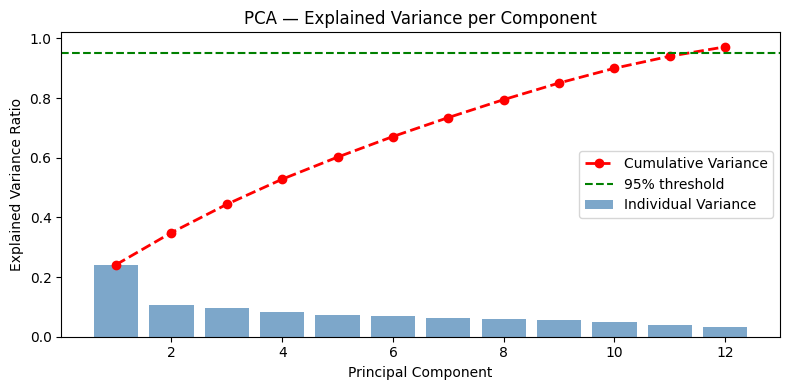

In [11]:
# PCA reduces the number of features by finding new axes
# (called principal components) that capture the most variance.
# We keep enough components to explain 95% of the total variance.

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

n_components_pca = pca.n_components_
print('PCA applied!')
print(f'Original features: {X_scaled.shape[1]}')
print(f'Components kept (95% variance): {n_components_pca}')
print()

# how much variance does each component explain?
print('Variance explained by each component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.2f}%)')

# plot explained variance
plt.figure(figsize=(8, 4))
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.bar(range(1, n_components_pca + 1), pca.explained_variance_ratio_,
        alpha=0.7, label='Individual Variance', color='steelblue')
plt.plot(range(1, n_components_pca + 1), cumulative_variance,
         'r--o', linewidth=2, label='Cumulative Variance')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance per Component')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — PCA 2D Visualization

Let's visually check if PCA separates the two classes (Alive vs Dead).

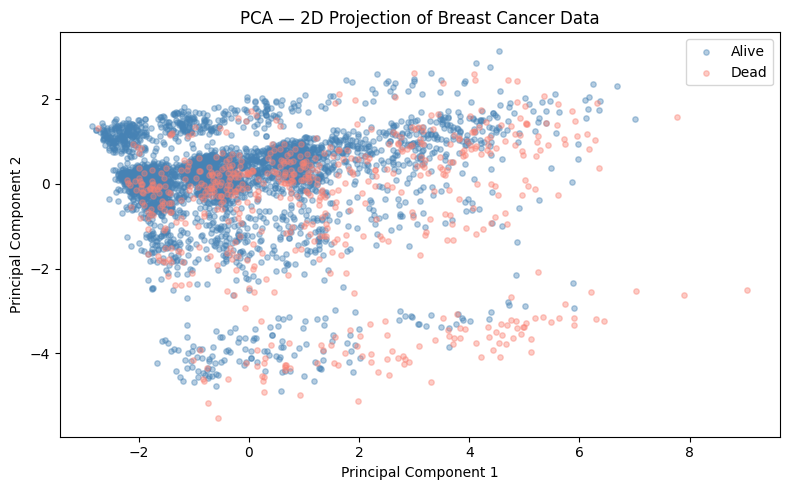

In [12]:
# We can plot the first 2 principal components to see if
# the classes (Alive / Dead) are somewhat separable

plt.figure(figsize=(8, 5))
colors = {0: 'steelblue', 1: 'salmon'}
labels_map = {0: 'Alive', 1: 'Dead'}

for cls in [0, 1]:
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.4, s=15)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA — 2D Projection of Breast Cancer Data')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — SVD (Singular Value Decomposition)

SVD is a matrix factorization technique used for dimensionality reduction.
Unlike PCA, it works on the raw matrix directly and handles sparse data well.

SVD applied!
Number of SVD components: 10
Total variance explained by SVD: 0.8998 (89.98%)

Top 5 Singular Values: [120.77  80.5   75.67  71.28  66.82]


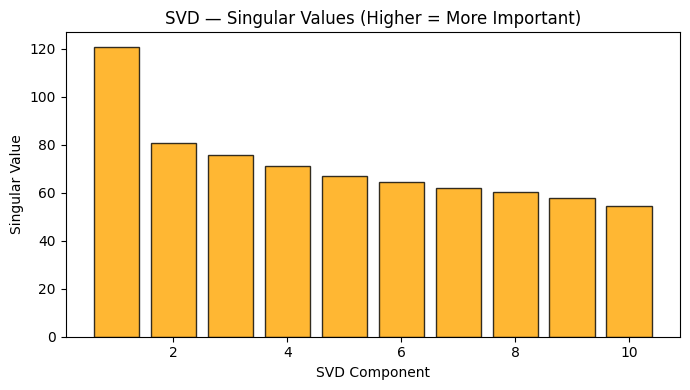

In [13]:
# SVD is another dimensionality reduction technique.
# It decomposes the data matrix into 3 matrices: U, Sigma, Vt
# TruncatedSVD keeps only the top k singular values/vectors.
# It works well even on sparse data (unlike PCA which needs dense).

n_svd = min(10, X_scaled.shape[1])  # we pick 10 components (or less if features < 10)
svd = TruncatedSVD(n_components=n_svd, random_state=42)
X_svd = svd.fit_transform(X_scaled)

print('SVD applied!')
print(f'Number of SVD components: {n_svd}')
print(f'Total variance explained by SVD: {svd.explained_variance_ratio_.sum():.4f} '
      f'({svd.explained_variance_ratio_.sum()*100:.2f}%)')
print()
print('Top 5 Singular Values:', svd.singular_values_[:5].round(2))

# plot singular values
plt.figure(figsize=(7, 4))
plt.bar(range(1, n_svd + 1), svd.singular_values_, color='orange', edgecolor='black', alpha=0.8)
plt.xlabel('SVD Component')
plt.ylabel('Singular Value')
plt.title('SVD — Singular Values (Higher = More Important)')
plt.tight_layout()
plt.show()

## Step 9 — Combine PCA + SVD → Train/Test Split

We concatenate the PCA and SVD features to create a rich combined representation, then split into train/test sets.

In [18]:
# We stack the PCA and SVD outputs together as our final feature set.
# This gives the model both types of compressed representations.

X_combined = np.hstack([X_pca, X_svd])
print('PCA features shape:', X_pca.shape)
print('SVD features shape:', X_svd.shape)
print('Combined features shape:', X_combined.shape)

# train/test split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # stratify ensures class ratio is maintained in both splits
)

print()
print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])
print('Train class distribution:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test class distribution: ', dict(zip(*np.unique(y_test, return_counts=True))))

PCA features shape: (4024, 12)
SVD features shape: (4024, 10)
Combined features shape: (4024, 22)

Train size: 3219
Test size:  805
Train class distribution: {np.int64(0): np.int64(2726), np.int64(1): np.int64(493)}
Test class distribution:  {np.int64(0): np.int64(682), np.int64(1): np.int64(123)}


## Step 10 — Train Multiple Models

We train **4 classifiers**:
1. Logistic Regression
2. SVM with RBF kernel
3. Random Forest
4. Voting Ensemble (combines all 3)

We also do **5-fold Cross Validation** to check how stable the results are.

In [15]:
# We will train 3 models and then combine them in a Voting Ensemble:
# 1. Logistic Regression — simple linear model, good baseline
# 2. SVM (Support Vector Machine) — finds best decision boundary
# 3. Random Forest — ensemble of decision trees

# class_weight='balanced' is important here because our dataset is imbalanced
# (more Alive samples than Dead) — this tells the model to treat both classes fairly

lr  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
svm = SVC(probability=True, class_weight='balanced', random_state=42)
rf  = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# Voting classifier combines all three models
# voting='soft' uses predicted probabilities (generally better than hard voting)
voting = VotingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('rf', rf)],
    voting='soft'
)

all_models = {
    'Logistic Regression': lr,
    'SVM (RBF Kernel)':    svm,
    'Random Forest':       rf,
    'Voting Ensemble':     voting
}

# 5-fold cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print('Training models... this may take a minute\n')
print('=' * 55)

for model_name, clf in all_models.items():
    print(f'Training: {model_name}...')

    clf.fit(X_train, y_train)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv_scores = cross_val_score(clf, X_combined, y, cv=cv, scoring='roc_auc')

    results[model_name] = {
        'clf':     clf,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     acc,
        'auc':     auc,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std()
    }

    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'  CV AUC   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()

print('=' * 55)

Training models... this may take a minute

Training: Logistic Regression...
  Accuracy : 0.8000
  ROC-AUC  : 0.8554
  CV AUC   : 0.8629 +/- 0.0135

Training: SVM (RBF Kernel)...
  Accuracy : 0.8037
  ROC-AUC  : 0.8168
  CV AUC   : 0.8418 +/- 0.0130

Training: Random Forest...
  Accuracy : 0.8944
  ROC-AUC  : 0.8303
  CV AUC   : 0.8390 +/- 0.0154

Training: Voting Ensemble...
  Accuracy : 0.8907
  ROC-AUC  : 0.8499
  CV AUC   : 0.8597 +/- 0.0140



## Step 11 — Identify the Best Model

We compare models using **ROC-AUC** score (better than accuracy for imbalanced datasets) and print a full classification report.

In [16]:
# We use ROC-AUC as the main metric because the dataset is imbalanced.
# A high AUC means the model is good at distinguishing Alive vs Dead.

best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]

print(f'Best model based on ROC-AUC: {best_name}')
print(f'AUC Score: {best["auc"]:.4f}')
print()
print('Detailed Classification Report:')
print('-' * 40)
print(classification_report(y_test, best['y_pred'], target_names=['Alive (0)', 'Dead (1)']))

Best model based on ROC-AUC: Logistic Regression
AUC Score: 0.8554

Detailed Classification Report:
----------------------------------------
              precision    recall  f1-score   support

   Alive (0)       0.94      0.82      0.87       682
    Dead (1)       0.41      0.71      0.52       123

    accuracy                           0.80       805
   macro avg       0.67      0.76      0.70       805
weighted avg       0.86      0.80      0.82       805



## Step 12 — ROC Curve Plot

The ROC curve shows the tradeoff between True Positive Rate and False Positive Rate. Higher AUC = better model.

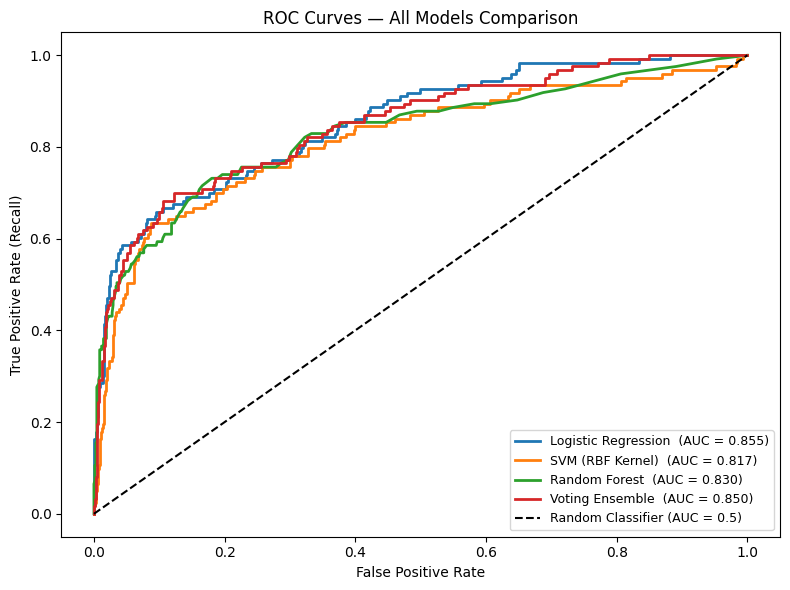

In [17]:
plt.figure(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name}  (AUC = {r['auc']:.3f})")

# diagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models Comparison')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 13 — Confusion Matrix

The confusion matrix shows how many predictions were correct vs wrong for each class.

In [ ]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive', 'Dead'])
disp.plot(colorbar=False, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

# let's also print what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Alive predicted as Alive): {tn}')
print(f'False Positives (Alive predicted as Dead):  {fp}')
print(f'False Negatives (Dead predicted as Alive):  {fn}')
print(f'True Positives  (Dead predicted as Dead):   {tp}')

## Step 14 — Model Comparison Chart

Bar chart to visually compare Accuracy and ROC-AUC across all models.

In [ ]:
model_names = list(results.keys())
auc_scores  = [results[n]['auc'] for n in model_names]
acc_scores  = [results[n]['acc'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, auc_scores, width, label='ROC-AUC',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, acc_scores, width, label='Accuracy', color='darkorange', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## Step 15 — Predict for a New Patient

Now we use the trained model to predict the outcome for a new (unseen) patient.
You can change the values in `sample_patient` to test different cases.

In [20]:
# This function takes patient details as input and predicts
# whether the patient is likely to be Alive or Dead.

def predict_new_patient(patient_info):
    """
    Predicts outcome for a new patient.

    Input:
        patient_info (dict): dictionary with all feature values

    Output:
        prints prediction result from all models
    """
    patient_df = pd.DataFrame([patient_info])

    for col in cat_cols:
        if col in patient_df.columns:
            patient_df[col] = le.fit_transform(patient_df[col].astype(str))

    for col in feature_cols:
        if col not in patient_df.columns:
            patient_df[col] = 0

    patient_df = patient_df[feature_cols]

    x_scaled = scaler.transform(patient_df.values)
    x_pca    = pca.transform(x_scaled)
    x_svd    = svd.transform(x_scaled)
    x_input  = np.hstack([x_pca, x_svd])

    print('=' * 50)
    print('       PATIENT PREDICTION RESULTS')
    print('=' * 50)

    for name, r in results.items():
        prob = r['clf'].predict_proba(x_input)[0][1]
        prediction = 'Dead' if prob >= 0.5 else 'Alive'
        marker = ' <-- Best Model' if name == best_name else ''
        print(f'  {name:<25} -> {prediction}  (Risk: {prob:.2%}){marker}')

    print('=' * 50)
    final_prob = results[best_name]['clf'].predict_proba(x_input)[0][1]
    final_pred = 'Dead' if final_prob >= 0.5 else 'Alive'
    confidence = max(final_prob, 1 - final_prob)
    print(f'  Final Prediction  : {final_pred}')
    print(f'  Confidence        : {confidence:.2%}')
    print('=' * 50)


# Example patient — you can change these values to test
sample_patient = {
    'Age': 55,
    'Race': 'White',
    'Marital Status': 'Married',
    'T Stage': 'T2',
    'N Stage': 'N1',
    '6th Stage': 'IIB',
    'differentiate': 'Moderately differentiated',
    'Grade': 2,
    'A Stage': 'Regional',
    'Tumor Size': 30,
    'Estrogen Status': 'Positive',
    'Progesterone Status': 'Positive',
    'Regional Node Examined': 10,
    'Reginol Node Positive': 2,
    'Survival Months': 24
}

predict_new_patient(sample_patient)

       PATIENT PREDICTION RESULTS
  Logistic Regression       -> Dead  (Risk: 82.24%) <-- Best Model
  SVM (RBF Kernel)          -> Alive  (Risk: 28.92%)
  Random Forest             -> Alive  (Risk: 43.50%)
  Voting Ensemble           -> Dead  (Risk: 51.55%)
  Final Prediction  : Dead
  Confidence        : 82.24%


## Step 16 — Save the Model

Save the trained model to a `.pkl` file so we don't have to retrain it every time.

In [19]:
# You can save the trained model to reuse later
# without retraining from scratch

model_to_save = {
    'scaler':        scaler,
    'pca':           pca,
    'svd':           svd,
    'label_encoder': le,
    'cat_cols':      cat_cols,
    'feature_cols':  feature_cols,
    'best_model':    best['clf'],
    'best_name':     best_name,
    'all_models':    {k: v['clf'] for k, v in results.items()}
}

joblib.dump(model_to_save, 'breast_cancer_model.pkl')
print("Model saved as 'breast_cancer_model.pkl'")
print()
print('To load it later:')
print('  import joblib')
print("  bundle = joblib.load('breast_cancer_model.pkl')")

# Download the saved model to your computer (Colab only)
# from google.colab import files
# files.download('breast_cancer_model.pkl')

print()


Model saved as 'breast_cancer_model.pkl'

To load it later:
  import joblib
  bundle = joblib.load('breast_cancer_model.pkl')

Done! Project complete.
